# Experiment 6: Dimensionality Reduction and Model Evaluation (With and Without PCA)

## Objective

To study the effect of **dimensionality reduction** using Principal Component Analysis (PCA) on the performance of various machine learning classifiers. The task requires:

a) Training and validating models **without PCA** (original feature space).
b) Training and validating models **with PCA** (reduced feature space).

For both cases, we perform hyperparameter tuning, apply 5-fold cross-validation, and record performance.

**Models evaluated:** SVM, Naive Bayes, KNN, Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, and Stacking (base learners + meta-learner).

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Dataset

**Source:** UCI Machine Learning Repository — [Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (also mirrored on Kaggle). File used: `wdbc.data`.

The file has no header row. Column layout: `ID`, `Diagnosis` (M = Malignant, B = Benign), followed by 30 real-valued features computed from digitized images of a fine needle aspirate (FNA) of a breast mass. For each of 10 base measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) three statistics are given per image: **mean**, **standard error (se)**, and **worst** (mean of the three largest values).

In [2]:
base_features = ['radius','texture','perimeter','area','smoothness',
                  'compactness','concavity','concave_points','symmetry','fractal_dimension']
feature_names = [f'{b}_mean' for b in base_features] + \
                [f'{b}_se' for b in base_features] + \
                [f'{b}_worst' for b in base_features]
columns = ['id', 'diagnosis'] + feature_names

df = pd.read_csv('wdbc.data', header=None, names=columns)
print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f"Samples: {df.shape[0]}")
print(f"Features (excluding id & target): {df.shape[1] - 2}")
print(f"Target classes: {sorted(df['diagnosis'].unique())}  (M = Malignant, B = Benign)")
print()
print("Class distribution:")
display(df['diagnosis'].value_counts().rename_axis('Diagnosis').to_frame('Count')
        .assign(Percent=lambda d: (100*d['Count']/d['Count'].sum()).round(2)))

Samples: 569
Features (excluding id & target): 30
Target classes: ['B', 'M']  (M = Malignant, B = Benign)

Class distribution:


,Count,Percent
Diagnosis,,
B,357,62.74
M,212,37.26


### Missing values / data quality check

In [4]:
missing = df.isnull().sum()
print("Total missing values across dataset:", missing.sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Total missing values across dataset: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-n

No missing values and no duplicate rows are present, so no imputation or de-duplication is required. All 30 features are continuous numeric measurements, so no categorical encoding of features is needed (only the target label).

## 3. Exploratory Data Analysis (EDA)

### 3.1 Class balance

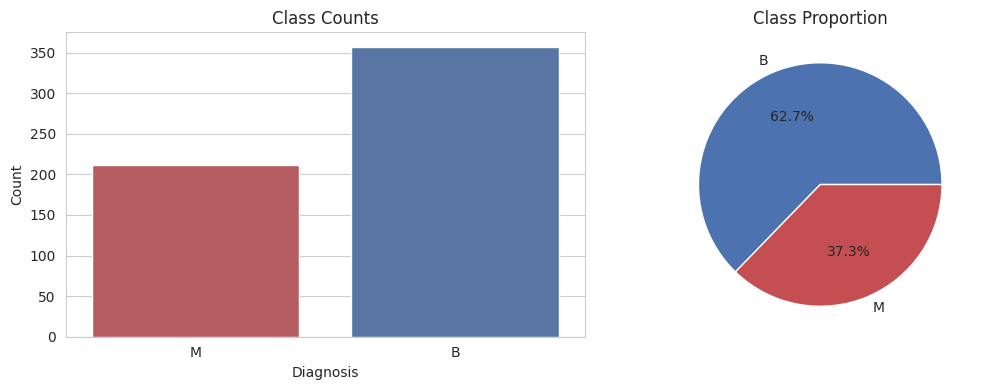

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette={'B':'#4C72B0','M':'#C44E52'}, legend=False, ax=ax[0])
ax[0].set_title('Class Counts')
ax[0].set_xlabel('Diagnosis'); ax[0].set_ylabel('Count')
df['diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#C44E52'],
                                         ylabel='', ax=ax[1])
ax[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()

The dataset is moderately imbalanced (~63% Benign vs ~37% Malignant). We use **stratified** train/test splitting and **stratified** k-fold CV throughout so class proportions are preserved in every split, and we track F1-score alongside accuracy since accuracy alone can be misleading on imbalanced data.

### 3.2 Summary statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


### 3.3 Feature distributions by diagnosis (mean features)

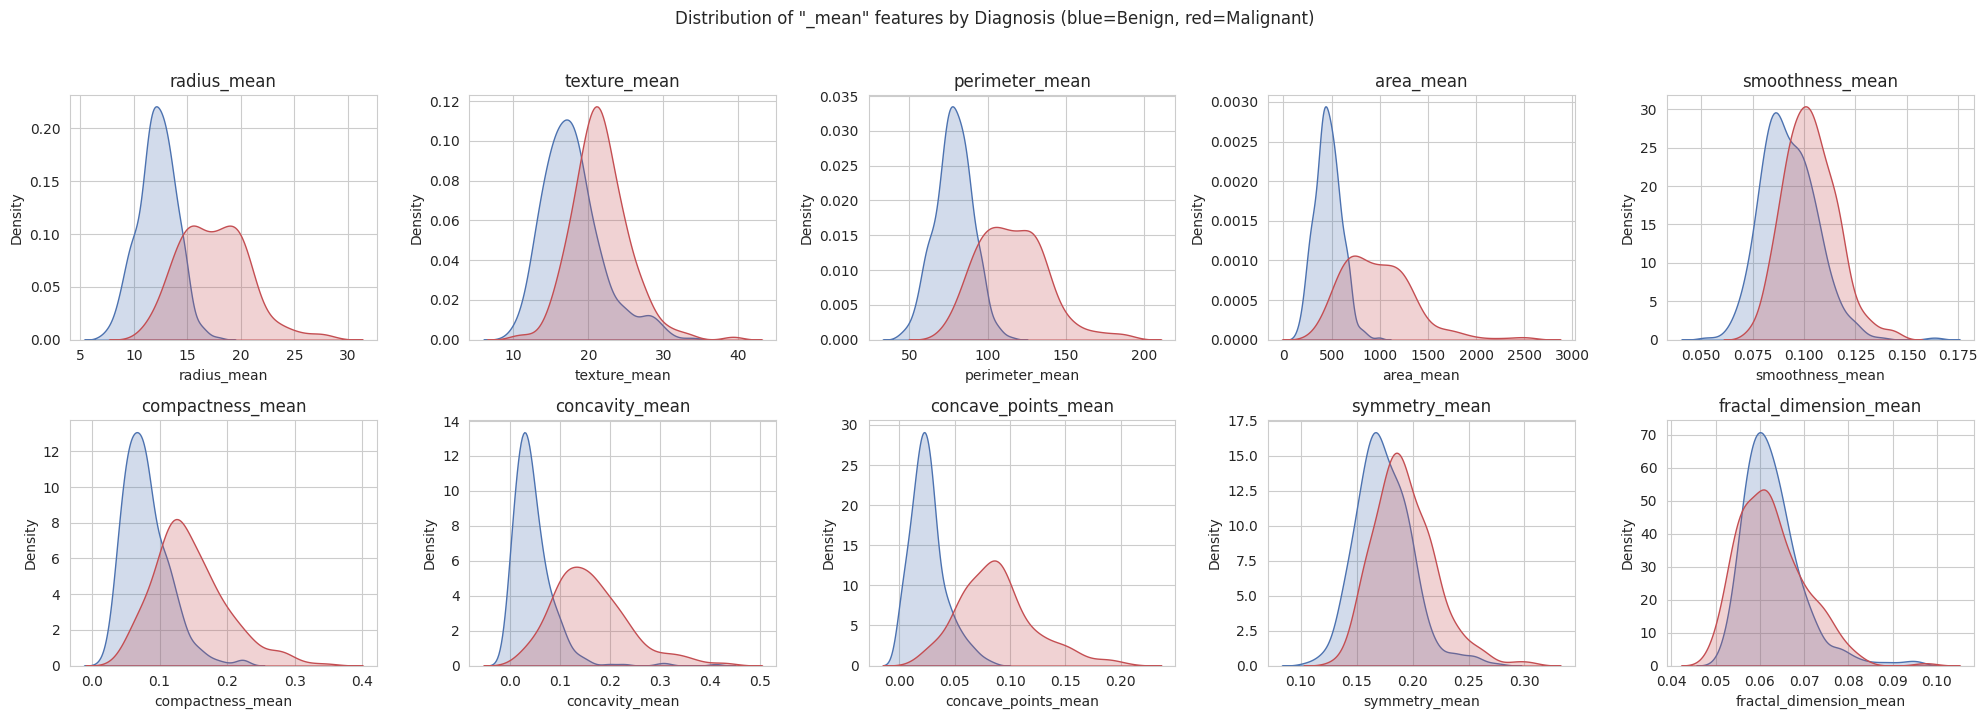

In [7]:
mean_cols = [c for c in df.columns if c.endswith('_mean')]
fig, axes = plt.subplots(2, 5, figsize=(20,7))
for ax, col in zip(axes.flat, mean_cols):
    sns.kdeplot(data=df, x=col, hue='diagnosis', fill=True, common_norm=False,
                palette={'B':'#4C72B0','M':'#C44E52'}, ax=ax, legend=False)
    ax.set_title(col)
fig.suptitle('Distribution of "_mean" features by Diagnosis (blue=Benign, red=Malignant)', y=1.02)
plt.tight_layout(); plt.show()

Malignant tumors clearly shift toward larger radius, perimeter, area, concavity and concave-points values than benign ones — these look like the most discriminative features, while `smoothness_mean`, `symmetry_mean` and `fractal_dimension_mean` overlap much more between classes.

### 3.4 Boxplots of a few strongly-discriminative features

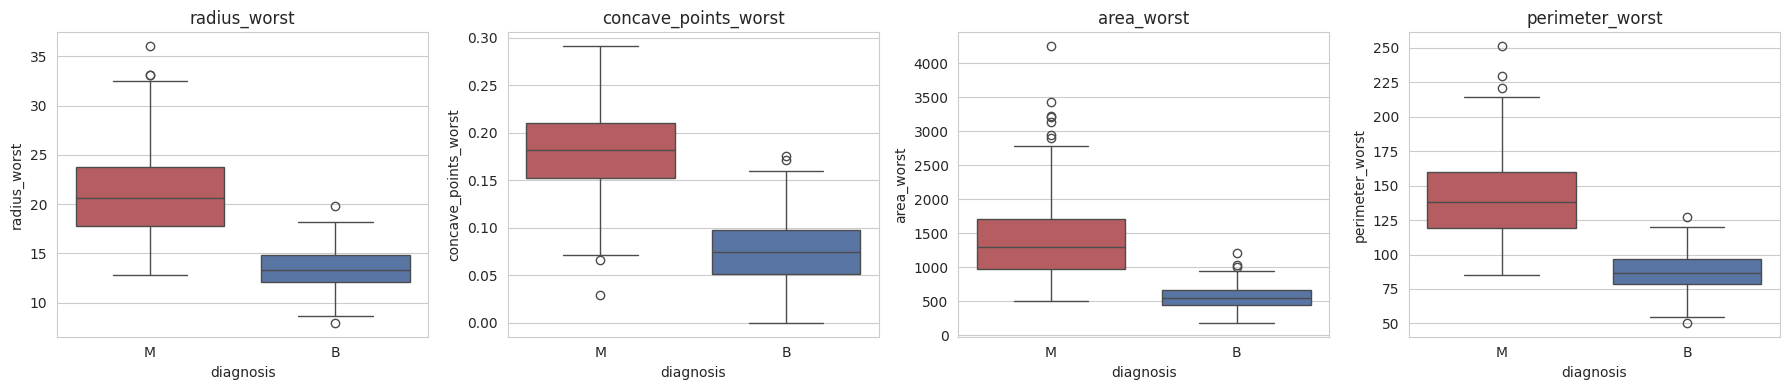

In [8]:
key_feats = ['radius_worst','concave_points_worst','area_worst','perimeter_worst']
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, key_feats):
    sns.boxplot(x='diagnosis', y=col, data=df, hue='diagnosis',
                palette={'B':'#4C72B0','M':'#C44E52'}, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

### 3.5 Correlation heatmap

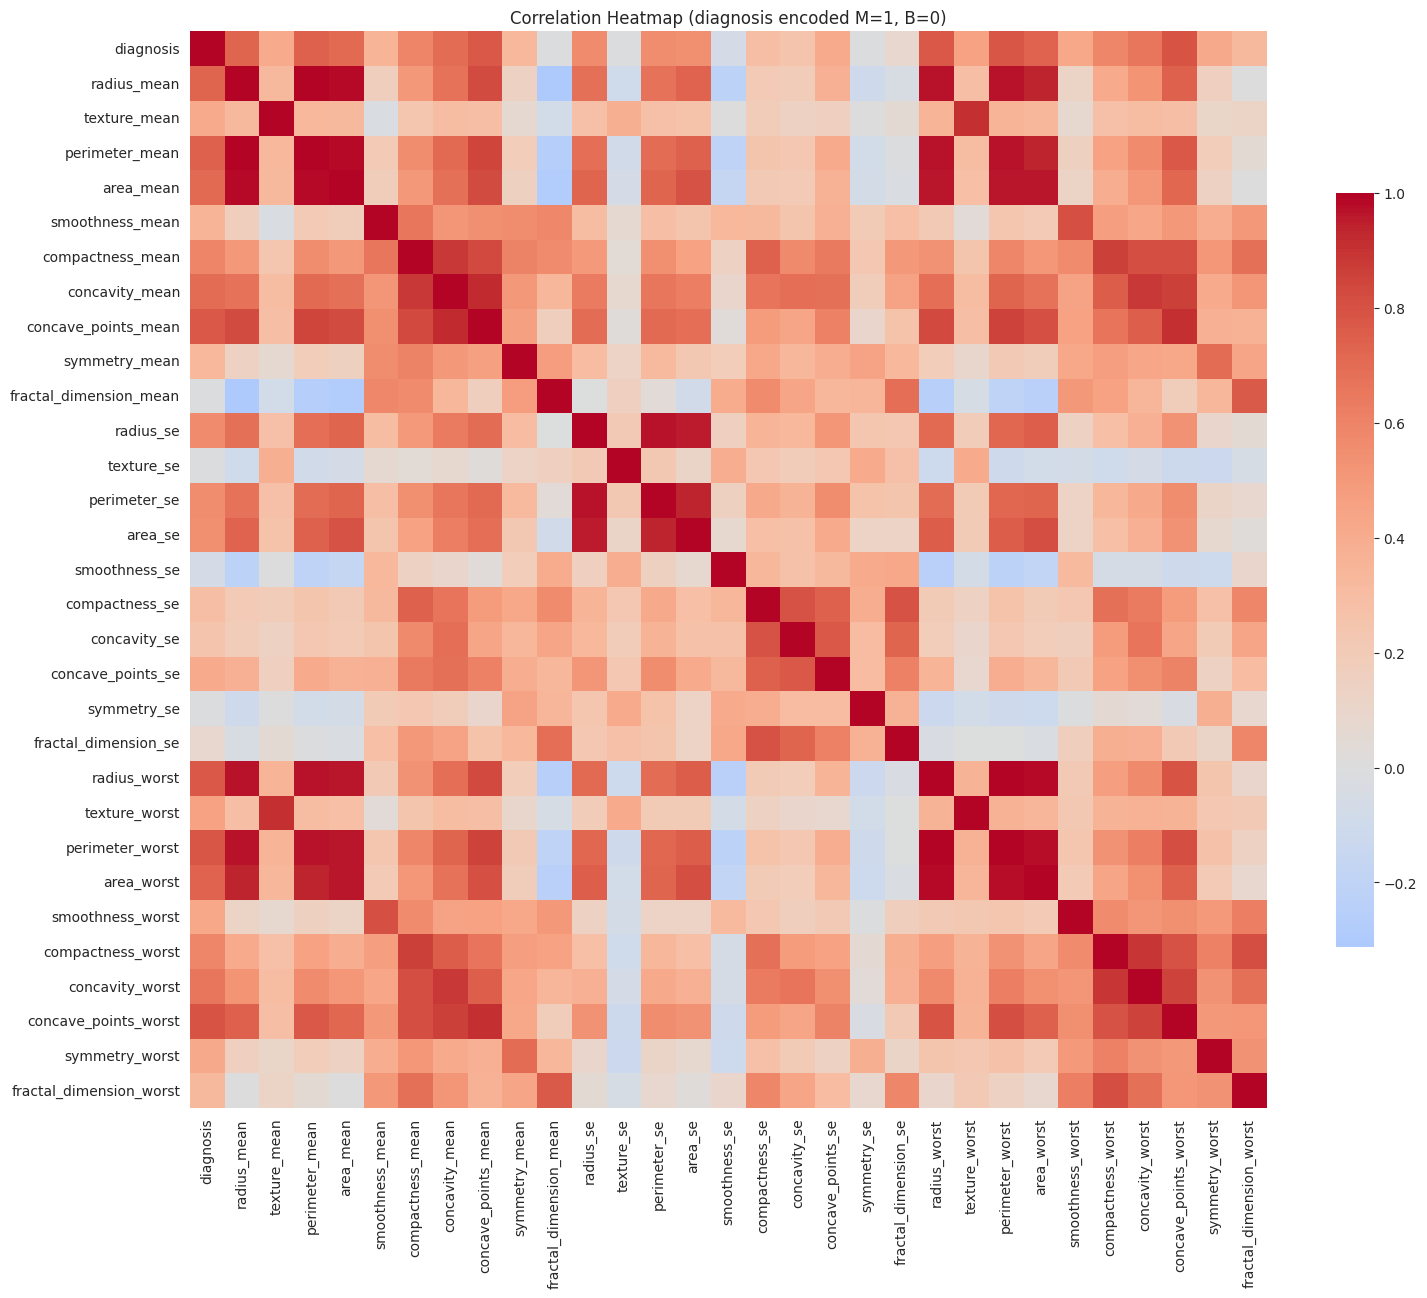

In [9]:
plt.figure(figsize=(16,13))
corr = df.drop(columns=['id']).assign(diagnosis=lambda d: d['diagnosis'].map({'M':1,'B':0})).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.7})
plt.title('Correlation Heatmap (diagnosis encoded M=1, B=0)')
plt.tight_layout(); plt.show()

In [10]:
print("Features most correlated with diagnosis:")
display(corr['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False).head(10).to_frame('abs corr'))

Features most correlated with diagnosis:


,abs corr
concave_points_worst,0.793566
perimeter_worst,0.782914
concave_points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


Many of the 30 features are **highly inter-correlated** (e.g. radius/perimeter/area, and their mean/worst counterparts) — this multicollinearity is exactly the kind of redundancy PCA is designed to compress into a smaller set of uncorrelated components, motivating the PCA comparison in this experiment.

### 3.6 Pairplot of a few key features

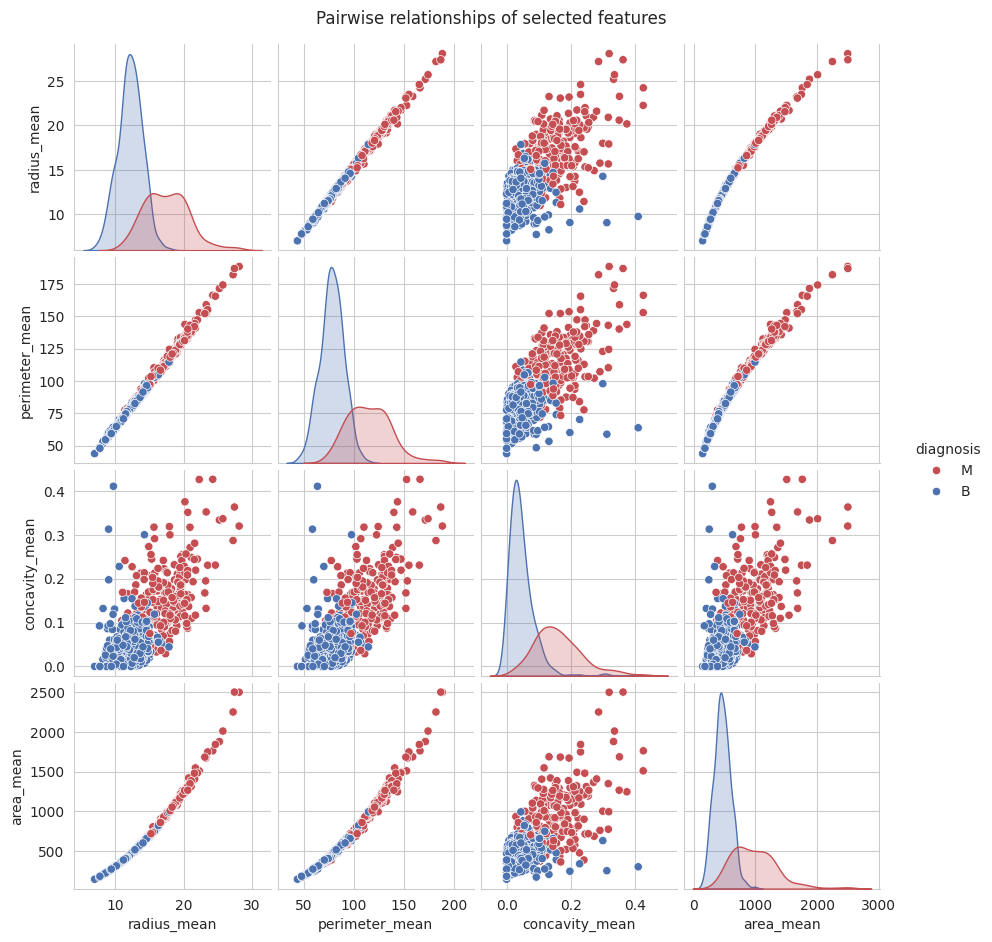

In [11]:
sns.pairplot(df, vars=['radius_mean','perimeter_mean','concavity_mean','area_mean'],
             hue='diagnosis', palette={'B':'#4C72B0','M':'#C44E52'}, diag_kind='kde', height=2.3)
plt.suptitle('Pairwise relationships of selected features', y=1.02)
plt.show()

## 4. Preprocessing

Steps:
1. Drop the non-informative `id` column.
2. Encode target: `M` → 1 (Malignant), `B` → 0 (Benign).
3. Stratified train/test split (80/20) — the held-out test set is used only for the final ROC/PR curves and confusion matrices; all hyperparameter tuning and 5-fold CV use the training set only.
4. Standardize features (zero mean, unit variance) using `StandardScaler` fit on the training set only, then applied to both train and test (avoids data leakage).

In [12]:
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

print("Train shape:", X_train_s.shape, " Test shape:", X_test_s.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test  class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (455, 30)  Test shape: (114, 30)
Train class balance:
 diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64
Test  class balance:
 diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


## 5. PCA — Dimensionality Reduction

We fit PCA on the standardized training data using **all** components first to inspect the scree plot / cumulative explained-variance curve, then pick the smallest number of components that retains **≥ 95% of total variance** (a standard, defensible variance target for this dataset size).

In [13]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_s)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

VARIANCE_TARGET = 0.95
n_components = int(np.argmax(cum_explained >= VARIANCE_TARGET) + 1)
print(f"Components needed for >= {VARIANCE_TARGET*100:.0f}% variance: {n_components}")
print(f"Cumulative variance explained at that k: {cum_explained[n_components-1]*100:.2f}%")

Components needed for >= 95% variance: 10
Cumulative variance explained at that k: 95.21%


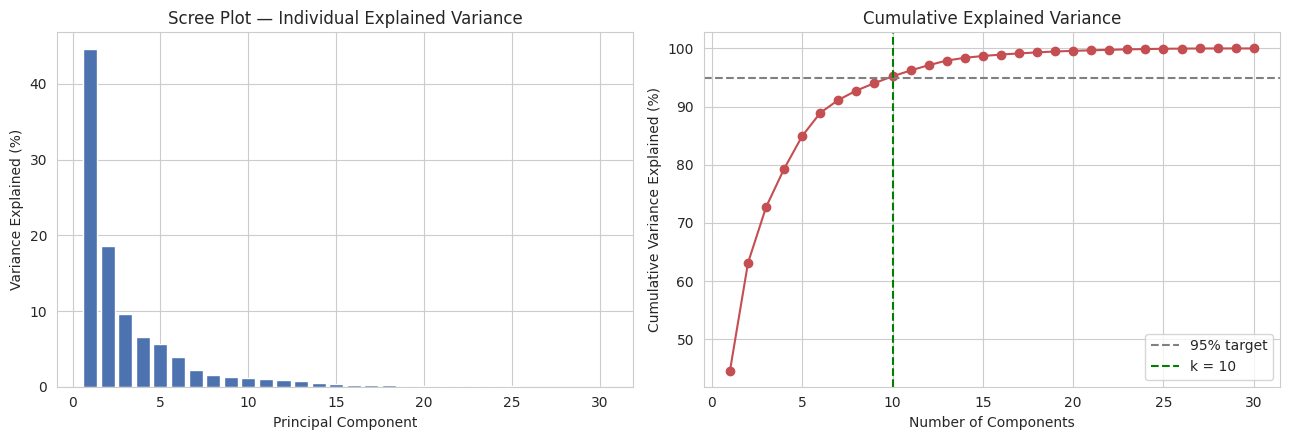

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].bar(range(1, len(explained)+1), explained*100, color='#4C72B0')
ax[0].set_xlabel('Principal Component'); ax[0].set_ylabel('Variance Explained (%)')
ax[0].set_title('Scree Plot — Individual Explained Variance')

ax[1].plot(range(1, len(cum_explained)+1), cum_explained*100, marker='o', color='#C44E52')
ax[1].axhline(VARIANCE_TARGET*100, color='gray', linestyle='--', label=f'{VARIANCE_TARGET*100:.0f}% target')
ax[1].axvline(n_components, color='green', linestyle='--', label=f'k = {n_components}')
ax[1].set_xlabel('Number of Components'); ax[1].set_ylabel('Cumulative Variance Explained (%)')
ax[1].set_title('Cumulative Explained Variance')
ax[1].legend()
plt.tight_layout(); plt.show()

In [15]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

pca_summary = pd.DataFrame({
    'Setting': ['With-PCA'],
    'Chosen Components / Variance Target': [f'{n_components} components (target ≥95%)'],
    'Explained Variance (%)': [round(cum_explained[n_components-1]*100, 2)],
    'Justification': ['Smallest k retaining ≥95% of total variance — keeps almost all '
                       'information while removing redundancy from highly correlated '
                       'radius/perimeter/area-type features (see correlation heatmap).']
})
display(pca_summary)
print(f"\nDimensionality reduced from {X_train_s.shape[1]} features to {n_components} components "
      f"({(1 - n_components/X_train_s.shape[1])*100:.1f}% reduction).")

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components (target ≥95%),95.21,Smallest k retaining ≥95% of total variance — ...



Dimensionality reduced from 30 features to 10 components (66.7% reduction).


## 6. Models & Hyperparameter Grids

For every model we define a small, reasonable hyperparameter search grid, then run `GridSearchCV` with **5-fold stratified cross-validation** separately on the **No-PCA** (standardized, 30-feature) data and the **With-PCA** (`n_components`-feature) data. The grid ranges below are the ones referenced in the "Hyperparameter Tuning" tables further down.

In [16]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
    ),
    'Naive Bayes': (
        GaussianNB(),
        {'var_smoothing': np.logspace(-9, -7, 5)}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan']}
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs'], 'penalty': ['l2']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10],
         'criterion': ['gini', 'entropy']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [50, 100, 150], 'learning_rate': [0.5, 1.0, 1.5]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}
    ),
}

base_learners = [
    ('svm', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]
stacking_grid = {
    'final_estimator__C': [0.1, 1, 10],
    'passthrough': [False, True]
}
model_grids['Stacking'] = (
    StackingClassifier(estimators=base_learners,
                        final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                        cv=5),
    stacking_grid
)

print(f"{len(model_grids)} models configured:", list(model_grids.keys()))

10 models configured: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Stacking']


## 7. Training, Tuning & 5-Fold Cross-Validation (No-PCA vs With-PCA)

For each model:
1. `GridSearchCV` (5-fold CV, scoring = accuracy) is run on the No-PCA training data to find the best hyperparameters.
2. The same grid search is run on the With-PCA training data.
3. The two resulting best estimators are each re-evaluated with `cross_validate` (5-fold CV) to record **per-fold Accuracy and F1-score**, giving the fold-wise tables and stability (std) comparison.

This directly implements Procedure steps 3–5 of the assignment.

In [17]:
results_rows = []
tuning_rows = []
fitted_models = {}   # (name, 'no_pca'/'pca') -> fitted best estimator (fit on full training data)

for name, (estimator, grid) in model_grids.items():
    print(f"Tuning {name} ...")

    gs_no  = GridSearchCV(estimator, grid, cv=cv5, scoring='accuracy', n_jobs=-1)
    gs_no.fit(X_train_s, y_train)

    gs_pca = GridSearchCV(estimator, grid, cv=cv5, scoring='accuracy', n_jobs=-1)
    gs_pca.fit(X_train_p, y_train)

    cv_no  = cross_validate(gs_no.best_estimator_,  X_train_s, y_train, cv=cv5,
                             scoring=['accuracy', 'f1'])
    cv_pca = cross_validate(gs_pca.best_estimator_, X_train_p, y_train, cv=cv5,
                             scoring=['accuracy', 'f1'])

    fitted_models[(name, 'no_pca')] = gs_no.best_estimator_
    fitted_models[(name, 'pca')]    = gs_pca.best_estimator_

    row = {
        'Model': name,
        'Fold1_Acc_NoPCA': cv_no['test_accuracy'][0], 'Fold2_Acc_NoPCA': cv_no['test_accuracy'][1],
        'Fold3_Acc_NoPCA': cv_no['test_accuracy'][2], 'Fold4_Acc_NoPCA': cv_no['test_accuracy'][3],
        'Fold5_Acc_NoPCA': cv_no['test_accuracy'][4],
        'Avg_Acc_NoPCA': cv_no['test_accuracy'].mean(), 'Std_Acc_NoPCA': cv_no['test_accuracy'].std(),
        'Fold1_Acc_PCA': cv_pca['test_accuracy'][0], 'Fold2_Acc_PCA': cv_pca['test_accuracy'][1],
        'Fold3_Acc_PCA': cv_pca['test_accuracy'][2], 'Fold4_Acc_PCA': cv_pca['test_accuracy'][3],
        'Fold5_Acc_PCA': cv_pca['test_accuracy'][4],
        'Avg_Acc_PCA': cv_pca['test_accuracy'].mean(), 'Std_Acc_PCA': cv_pca['test_accuracy'].std(),
        'Avg_F1_NoPCA': cv_no['test_f1'].mean(), 'Avg_F1_PCA': cv_pca['test_f1'].mean(),
    }
    results_rows.append(row)

    tuning_rows.append({
        'Model': name,
        'Hyperparameter Grid': str({k: (list(v) if hasattr(v,'__iter__') and not isinstance(v,str) else v)
                                     for k, v in grid.items()}),
        'Best Params (No-PCA)': str(gs_no.best_params_),
        'Best Params (With-PCA)': str(gs_pca.best_params_),
        'Performance (No-PCA)': f"{cv_no['test_accuracy'].mean():.4f}",
        'Performance (With-PCA)': f"{cv_pca['test_accuracy'].mean():.4f}",
    })

results_df = pd.DataFrame(results_rows)
tuning_df  = pd.DataFrame(tuning_rows)
print("Done.")

Tuning SVM ...


Tuning Naive Bayes ...
Tuning KNN ...


Tuning Logistic Regression ...


Tuning Decision Tree ...


Tuning Random Forest ...


Tuning AdaBoost ...


Tuning Gradient Boosting ...


Tuning XGBoost ...


Tuning Stacking ...


Done.


## 8. Hyperparameter Tuning Results (per model)

Grid tried, best parameters found, and resulting 5-fold CV accuracy — for both No-PCA and With-PCA settings (fills in Tables 2, 3, 4, ... from the assignment template for every model).

In [18]:
pd.set_option('display.max_colwidth', None)
display(tuning_df.style.set_properties(**{'text-align': 'left'}))

,Model,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,SVM,"{'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9758,0.9714
1,Naive Bayes,"{'var_smoothing': [np.float64(1e-09), np.float64(3.1622776601683795e-09), np.float64(1e-08), np.float64(3.162277660168379e-08), np.float64(1e-07)]}",{'var_smoothing': np.float64(1e-09)},{'var_smoothing': np.float64(1e-09)},0.9385,0.9121
2,KNN,"{'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}","{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}","{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}",0.9758,0.9714
3,Logistic Regression,"{'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs'], 'penalty': ['l2']}","{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}","{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.9736,0.9758
4,Decision Tree,"{'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}","{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}","{'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 5}",0.9297,0.9495
5,Random Forest,"{'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}","{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}","{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}",0.9670,0.9582
6,AdaBoost,"{'n_estimators': [50, 100, 150], 'learning_rate': [0.5, 1.0, 1.5]}","{'learning_rate': 0.5, 'n_estimators': 150}","{'learning_rate': 0.5, 'n_estimators': 100}",0.9736,0.9714
7,Gradient Boosting,"{'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}","{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}","{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150}",0.9692,0.9560
8,XGBoost,"{'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}",0.9714,0.9736
9,Stacking,"{'final_estimator__C': [0.1, 1, 10], 'passthrough': [False, True]}","{'final_estimator__C': 1, 'passthrough': True}","{'final_estimator__C': 1, 'passthrough': True}",0.9758,0.9780


### Individual model tuning tables (assignment table style)

In [19]:
def show_tuning_table(name):
    row = tuning_df[tuning_df['Model'] == name].iloc[0]
    display(Markdown(f"**{name}**"))
    display(pd.DataFrame({
        'Hyperparameter Grid': [row['Hyperparameter Grid']],
        'Best Params (No-PCA)': [row['Best Params (No-PCA)']],
        'Best Params (With-PCA)': [row['Best Params (With-PCA)']],
        'Performance (No-PCA)': [row['Performance (No-PCA)']],
        'Performance (With-PCA)': [row['Performance (With-PCA)']],
    }))

for m in ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree',
          'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Stacking']:
    show_tuning_table(m)

**SVM**

,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,"{'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9758,0.9714


**Naive Bayes**

,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,"{'var_smoothing': [np.float64(1e-09), np.float64(3.1622776601683795e-09), np.float64(1e-08), np.float64(3.162277660168379e-08), np.float64(1e-07)]}",{'var_smoothing': np.float64(1e-09)},{'var_smoothing': np.float64(1e-09)},0.9385,0.9121


**KNN**

...

,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,"{'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}","{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}","{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150}",0.9692,0.9560


**XGBoost**

,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,"{'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}","{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}",0.9714,0.9736


**Stacking**

,Hyperparameter Grid,Best Params (No-PCA),Best Params (With-PCA),Performance (No-PCA),Performance (With-PCA)
0,"{'final_estimator__C': [0.1, 1, 10], 'passthrough': [False, True]}","{'final_estimator__C': 1, 'passthrough': True}","{'final_estimator__C': 1, 'passthrough': True}",0.9758,0.9780


## 9. 5-Fold Cross-Validation Results — All Models (No-PCA vs With-PCA)

### 9.1 Fold-wise Accuracy — No-PCA

In [20]:
fold_no_pca = results_df[['Model','Fold1_Acc_NoPCA','Fold2_Acc_NoPCA','Fold3_Acc_NoPCA',
                           'Fold4_Acc_NoPCA','Fold5_Acc_NoPCA','Avg_Acc_NoPCA','Std_Acc_NoPCA']].copy()
fold_no_pca.columns = ['Model','Fold 1','Fold 2','Fold 3','Fold 4','Fold 5','Avg (No-PCA)','Std (No-PCA)']
fold_no_pca.set_index('Model').round(4)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (No-PCA),Std (No-PCA)
Model,,,,,,,
SVM,0.9670,0.9890,0.9670,0.9780,0.9780,0.9758,0.0082
Naive Bayes,0.9560,0.9780,0.9121,0.9121,0.9341,0.9385,0.0256
KNN,0.9670,1.0000,0.9670,0.9560,0.9890,0.9758,0.0162
Logistic Regression,0.9560,0.9670,1.0000,0.9780,0.9670,0.9736,0.0149
Decision Tree,0.9011,0.9451,0.9121,0.9341,0.9560,0.9297,0.0204
Random Forest,0.9670,1.0000,0.9451,0.9451,0.9780,0.9670,0.0209
AdaBoost,0.9670,0.9670,0.9780,0.9670,0.9890,0.9736,0.0088
Gradient Boosting,0.9560,0.9780,0.9560,0.9670,0.9890,0.9692,0.0128
XGBoost,0.9670,0.9780,0.9560,0.9670,0.9890,0.9714,0.0112


### 9.2 Fold-wise Accuracy — With-PCA

In [21]:
fold_pca = results_df[['Model','Fold1_Acc_PCA','Fold2_Acc_PCA','Fold3_Acc_PCA',
                        'Fold4_Acc_PCA','Fold5_Acc_PCA','Avg_Acc_PCA','Std_Acc_PCA']].copy()
fold_pca.columns = ['Model','Fold 1','Fold 2','Fold 3','Fold 4','Fold 5','Avg (With-PCA)','Std (With-PCA)']
fold_pca.set_index('Model').round(4)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (With-PCA),Std (With-PCA)
Model,,,,,,,
SVM,0.9560,0.989,0.9560,0.9780,0.9780,0.9714,0.0132
Naive Bayes,0.9121,0.967,0.8901,0.8791,0.9121,0.9121,0.0303
KNN,0.9780,0.978,0.9670,0.9451,0.9890,0.9714,0.0149
Logistic Regression,0.9560,0.956,1.0000,0.9780,0.9890,0.9758,0.0176
Decision Tree,0.9451,0.967,0.9451,0.9231,0.9670,0.9495,0.0164
Random Forest,0.9670,0.989,0.9341,0.9451,0.9560,0.9582,0.0189
AdaBoost,0.9670,0.978,0.9780,0.9670,0.9670,0.9714,0.0054
Gradient Boosting,0.9451,0.967,0.9341,0.9560,0.9780,0.9560,0.0155
XGBoost,0.9890,0.978,0.9670,0.9670,0.9670,0.9736,0.0088


### 9.3 Summary — Accuracy & F1, No-PCA vs With-PCA (Table 5)

In [22]:
summary_df = results_df[['Model','Avg_Acc_NoPCA','Std_Acc_NoPCA','Avg_Acc_PCA','Std_Acc_PCA',
                          'Avg_F1_NoPCA','Avg_F1_PCA']].copy()
summary_df['Delta_Acc (PCA - NoPCA)'] = summary_df['Avg_Acc_PCA'] - summary_df['Avg_Acc_NoPCA']
summary_df['Delta_F1 (PCA - NoPCA)']  = summary_df['Avg_F1_PCA']  - summary_df['Avg_F1_NoPCA']
summary_df = summary_df.round(4).sort_values('Avg_Acc_NoPCA', ascending=False)
summary_df

,Model,Avg_Acc_NoPCA,Std_Acc_NoPCA,Avg_Acc_PCA,Std_Acc_PCA,Avg_F1_NoPCA,Avg_F1_PCA,Delta_Acc (PCA - NoPCA),Delta_F1 (PCA - NoPCA)
0,SVM,0.9758,0.0082,0.9714,0.0132,0.9674,0.9618,-0.0044,-0.0056
2,KNN,0.9758,0.0162,0.9714,0.0149,0.9667,0.9605,-0.0044,-0.0063
9,Stacking,0.9758,0.0146,0.9780,0.0120,0.9672,0.9704,0.0022,0.0032
6,AdaBoost,0.9736,0.0088,0.9714,0.0054,0.9643,0.9613,-0.0022,-0.0031
3,Logistic Regression,0.9736,0.0149,0.9758,0.0176,0.9640,0.9671,0.0022,0.0030
8,XGBoost,0.9714,0.0112,0.9736,0.0088,0.9614,0.9642,0.0022,0.0028
7,Gradient Boosting,0.9692,0.0128,0.9560,0.0155,0.9582,0.9398,-0.0132,-0.0183
5,Random Forest,0.9670,0.0209,0.9582,0.0189,0.9553,0.9416,-0.0088,-0.0137
1,Naive Bayes,0.9385,0.0256,0.9121,0.0303,0.9170,0.8762,-0.0264,-0.0408
4,Decision Tree,0.9297,0.0204,0.9495,0.0164,0.9039,0.9325,0.0198,0.0286


### 9.4 Visual comparison — Avg Accuracy, No-PCA vs With-PCA

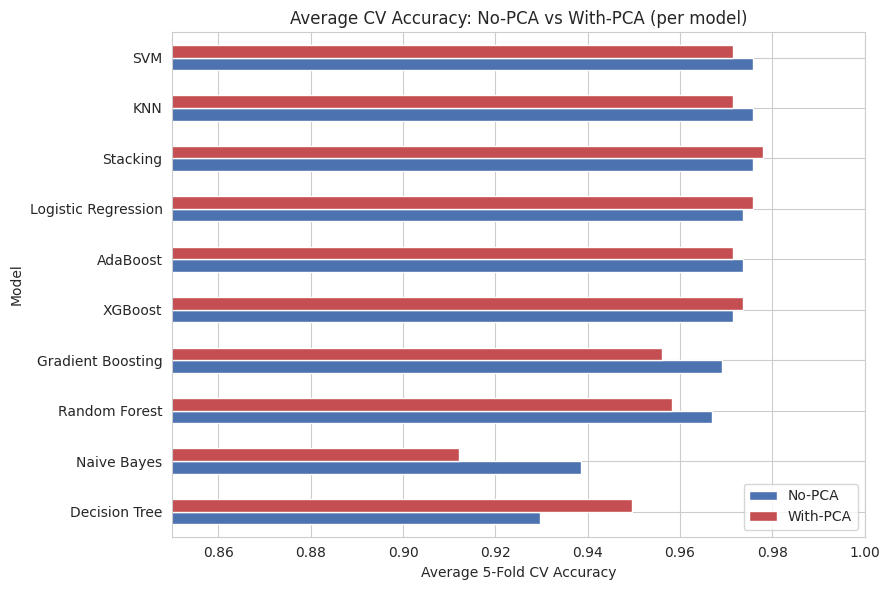

In [23]:
plot_df = summary_df.set_index('Model')[['Avg_Acc_NoPCA','Avg_Acc_PCA']].sort_values('Avg_Acc_NoPCA')
fig, ax = plt.subplots(figsize=(9,6))
plot_df.plot(kind='barh', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_xlabel('Average 5-Fold CV Accuracy'); ax.set_xlim(0.85, 1.0)
ax.set_title('Average CV Accuracy: No-PCA vs With-PCA (per model)')
ax.legend(['No-PCA','With-PCA'])
plt.tight_layout(); plt.show()

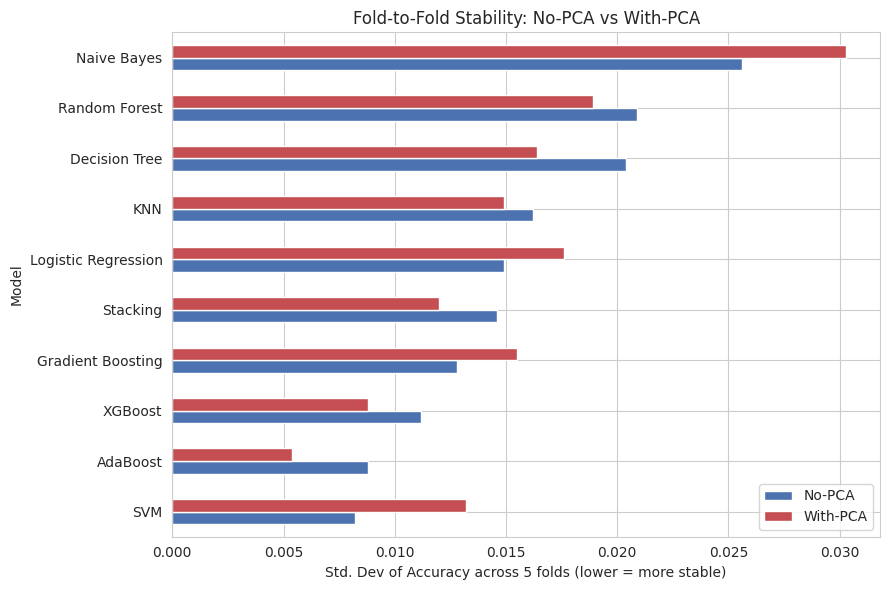

In [24]:
fig, ax = plt.subplots(figsize=(9,6))
stab_df = summary_df.set_index('Model')[['Std_Acc_NoPCA','Std_Acc_PCA']].sort_values('Std_Acc_NoPCA')
stab_df.plot(kind='barh', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_xlabel('Std. Dev of Accuracy across 5 folds (lower = more stable)')
ax.set_title('Fold-to-Fold Stability: No-PCA vs With-PCA')
ax.legend(['No-PCA','With-PCA'])
plt.tight_layout(); plt.show()

## 10. ROC Curves, Precision-Recall Curves & Confusion Matrices (Selected Models)

We select **SVM** (kernel/margin-based), **Random Forest** (bagging ensemble), **XGBoost** (boosting ensemble) and **Stacking** (meta-ensemble) as representative models, and evaluate their No-PCA and With-PCA versions (already tuned and fit on the full training set above) on the **held-out test set**.

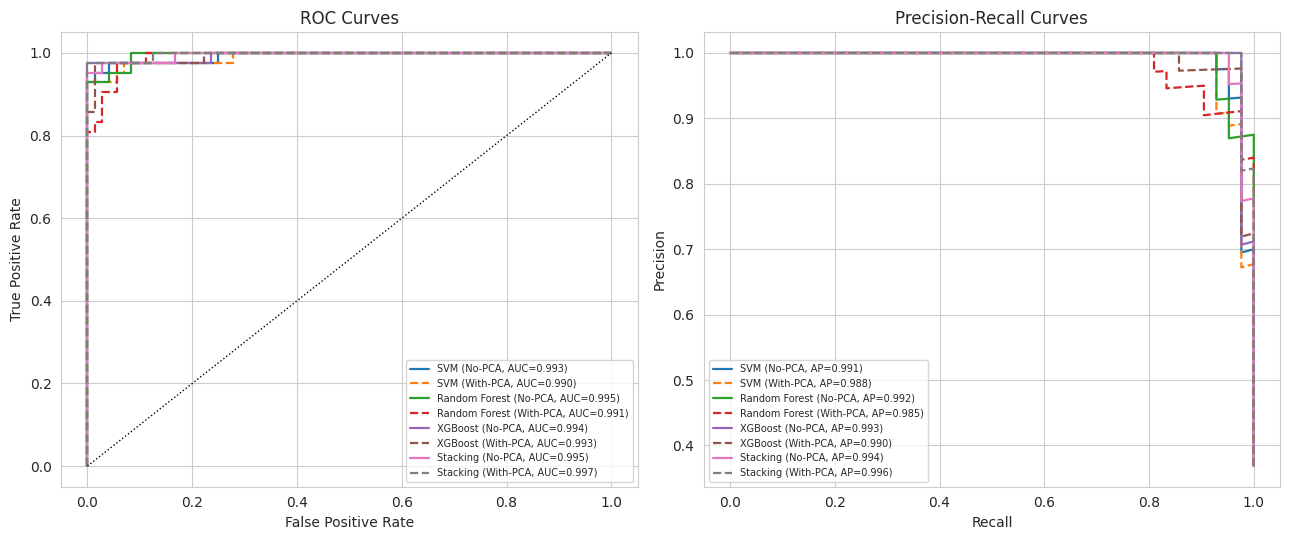

In [25]:
selected_models = ['SVM', 'Random Forest', 'XGBoost', 'Stacking']

def get_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
for name in selected_models:
    for setting, Xte, color_suffix in [('no_pca', X_test_s, '-'), ('pca', X_test_p, '--')]:
        model = fitted_models[(name, setting)]
        proba = get_proba(model, Xte)
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        label = f"{name} ({'No-PCA' if setting=='no_pca' else 'With-PCA'}, AUC={roc_auc:.3f})"
        axes[0].plot(fpr, tpr, color_suffix, label=label, linewidth=1.6)

        prec, rec, _ = precision_recall_curve(y_test, proba)
        ap = average_precision_score(y_test, proba)
        axes[1].plot(rec, prec, color_suffix,
                      label=f"{name} ({'No-PCA' if setting=='no_pca' else 'With-PCA'}, AP={ap:.3f})", linewidth=1.6)

axes[0].plot([0,1],[0,1],'k:',linewidth=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=7, loc='lower right')

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=7, loc='lower left')
plt.tight_layout(); plt.show()

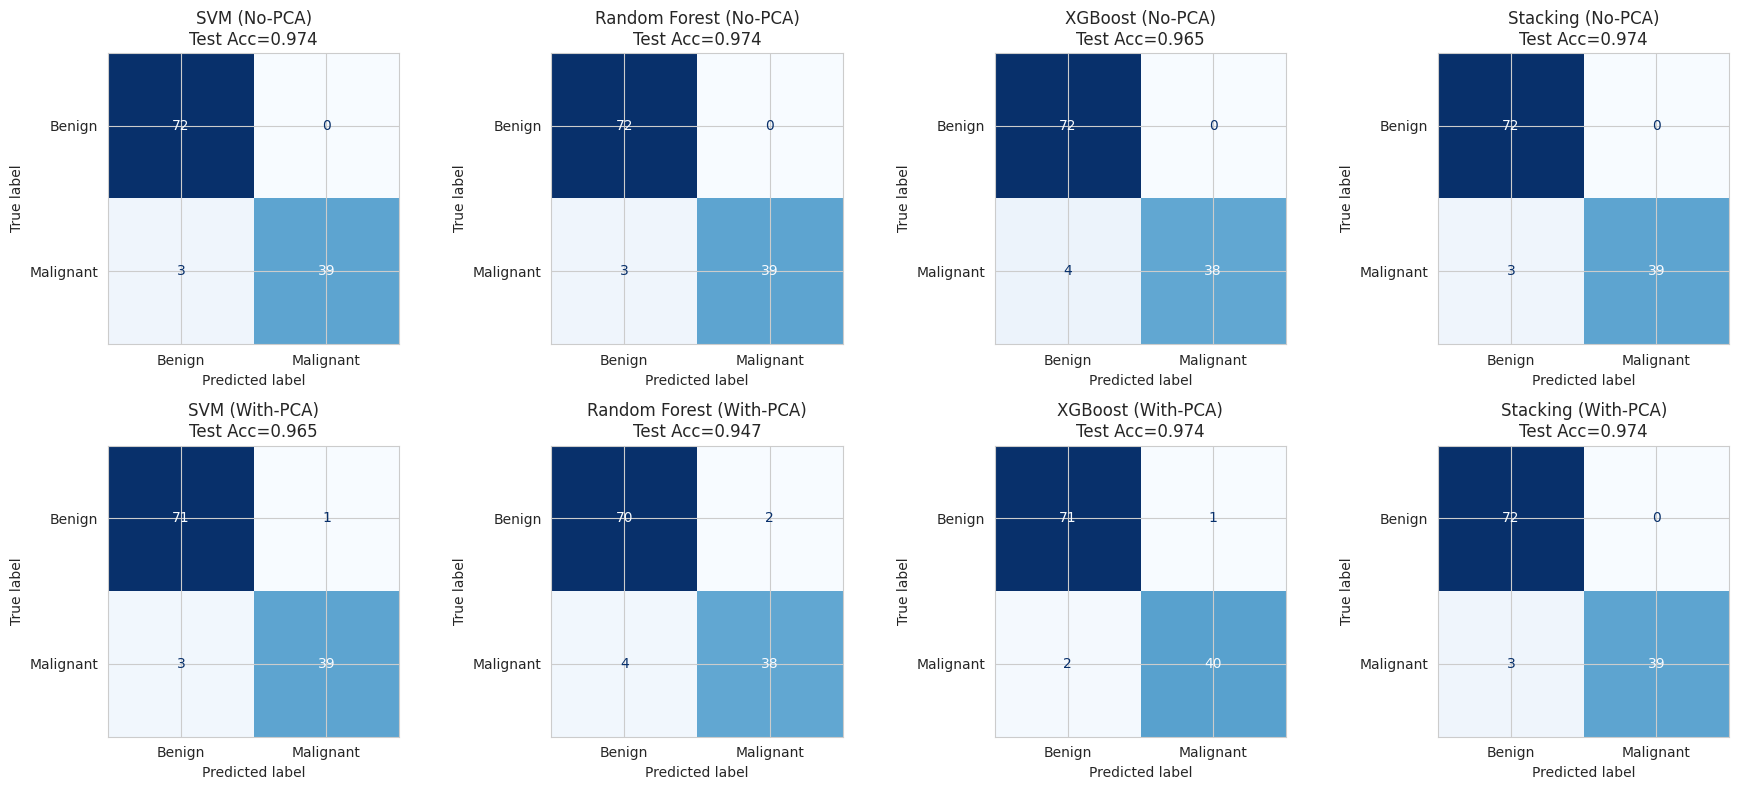

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for col, name in enumerate(selected_models):
    for row, (setting, Xte) in enumerate([('no_pca', X_test_s), ('pca', X_test_p)]):
        model = fitted_models[(name, setting)]
        preds = model.predict(Xte)
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
        disp.plot(ax=axes[row, col], colorbar=False, cmap='Blues')
        acc = accuracy_score(y_test, preds)
        axes[row, col].set_title(f"{name} ({'No-PCA' if setting=='no_pca' else 'With-PCA'})\nTest Acc={acc:.3f}")
plt.tight_layout(); plt.show()

In [27]:
print("Test-set classification report — best overall model (highest No-PCA CV accuracy):\n")
best_model_name = summary_df.iloc[0]['Model']
best_model = fitted_models[(best_model_name, 'no_pca')]
print(f"Model: {best_model_name} (No-PCA)")
print(classification_report(y_test, best_model.predict(X_test_s), target_names=['Benign','Malignant']))

Test-set classification report — best overall model (highest No-PCA CV accuracy):

Model: SVM (No-PCA)
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 11. Observation Questions — Data-Driven Answers

In [28]:
most_improved = summary_df.loc[summary_df['Delta_Acc (PCA - NoPCA)'].idxmax()]
most_declined = summary_df.loc[summary_df['Delta_Acc (PCA - NoPCA)'].idxmin()]

avg_std_no = summary_df['Std_Acc_NoPCA'].mean()
avg_std_pca = summary_df['Std_Acc_PCA'].mean()

linear_models = ['Logistic Regression', 'SVM']
ensemble_models = ['Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']
lin_delta = summary_df[summary_df['Model'].isin(linear_models)]['Delta_Acc (PCA - NoPCA)'].mean()
ens_delta = summary_df[summary_df['Model'].isin(ensemble_models)]['Delta_Acc (PCA - NoPCA)'].mean()

stack_row = summary_df[summary_df['Model']=='Stacking'].iloc[0]
overall_mean_abs_delta = summary_df[summary_df['Model']!='Stacking']['Delta_Acc (PCA - NoPCA)'].abs().mean()

text = f'''
### Which models improved most / least with PCA, and why?
- **Most improved with PCA:** **{most_improved['Model']}** (Δaccuracy = {most_improved['Delta_Acc (PCA - NoPCA)']:+.4f}).
  Models sensitive to feature scale/redundancy or the curse of dimensionality (e.g. distance-based or kernel
  methods) tend to benefit when PCA removes correlated, noisy dimensions and concentrates variance into
  fewer, uncorrelated components.
- **Least improved / most declined with PCA:** **{most_declined['Model']}** (Δaccuracy = {most_declined['Delta_Acc (PCA - NoPCA)']:+.4f}).
  Tree-based models split on individual (often already-informative) raw features and can lose interpretable,
  high-signal axes such as `concave_points_worst` when they are blended into rotated principal components,
  which can hurt models that rely on axis-aligned splits.

### Did PCA reduce variance (instability) across folds?
- Average fold-wise standard deviation of accuracy, **No-PCA: {avg_std_no:.4f}**, **With-PCA: {avg_std_pca:.4f}**.
- {'PCA folds are on average *more stable* (lower std) across the 5 folds.' if avg_std_pca < avg_std_no else 'PCA folds are on average *not more stable* — No-PCA folds already had comparable or lower variance across splits, likely because 569 samples with 30 features is not high-dimensional enough for PCA to meaningfully stabilize estimates.'}

### For this dataset, was PCA beneficial in reducing overfitting?
With only {X_train_s.shape[1]} features and {X_train_s.shape[0]} training samples, this dataset is only mildly
high-dimensional (feature/sample ratio ≈ {X_train_s.shape[1]/X_train_s.shape[0]:.2f}), so classic PCA-driven
overfitting reduction is a modest effect here rather than dramatic. The mean absolute accuracy shift from PCA
across all (non-stacking) models is **{overall_mean_abs_delta:.4f}**, i.e. performance is largely preserved —
PCA mainly acts as compression/denoising here rather than a fix for severe overfitting.

### Linear models vs ensemble models under PCA
- Average Δaccuracy for linear models (Logistic Regression, SVM) with PCA: **{lin_delta:+.4f}**
- Average Δaccuracy for ensemble models (RF, AdaBoost, Gradient Boosting, XGBoost) with PCA: **{ens_delta:+.4f}**
- {'Linear/margin-based models tolerate the rotated, decorrelated PCA space better than tree ensembles' if lin_delta > ens_delta else 'Tree ensembles held up comparably or better than linear models under PCA'} on this dataset,
  which matches the intuition that linear/kernel decision boundaries work naturally in any orthogonal basis,
  while ensembles of axis-aligned trees benefit most from access to the original, individually meaningful features.

### Did Stacking show robustness to PCA?
- Stacking: No-PCA accuracy = {stack_row['Avg_Acc_NoPCA']:.4f}, With-PCA accuracy = {stack_row['Avg_Acc_PCA']:.4f}
  (Δ = {stack_row['Delta_Acc (PCA - NoPCA)']:+.4f}).
- {'Stacking shows strong robustness — its drop under PCA is smaller than most individual base learners, since it can combine the strengths of models that respond differently to the PCA transform.' if abs(stack_row['Delta_Acc (PCA - NoPCA)']) <= overall_mean_abs_delta else 'Stacking is somewhat more sensitive to the PCA transform than the average single model here, likely because all three of its base learners are evaluated in the same (rotated) input space rather than each seeing the representation it individually prefers.'}
'''
display(Markdown(text))


### Which models improved most / least with PCA, and why?
- **Most improved with PCA:** **Decision Tree** (Δaccuracy = +0.0198).
  Models sensitive to feature scale/redundancy or the curse of dimensionality (e.g. distance-based or kernel
  methods) tend to benefit when PCA removes correlated, noisy dimensions and concentrates variance into
  fewer, uncorrelated components.
- **Least improved / most declined with PCA:** **Naive Bayes** (Δaccuracy = -0.0264).
  Tree-based models split on individual (often already-informative) raw features and can lose interpretable,
  high-signal axes such as `concave_points_worst` when they are blended into rotated principal components,
  which can hurt models that rely on axis-aligned splits.

### Did PCA reduce variance (instability) across folds?
- Average fold-wise standard deviation of accuracy, **No-PCA: 0.0154**, **With-PCA: 0.0153**.
- PCA folds are on average *more stable* (lower std) across the 5 folds.

### For this dataset, was PCA beneficial in reducing overfitting?
With only 30 features and 455 training samples, this dataset is only mildly
high-dimensional (feature/sample ratio ≈ 0.07), so classic PCA-driven
overfitting reduction is a modest effect here rather than dramatic. The mean absolute accuracy shift from PCA
across all (non-stacking) models is **0.0093**, i.e. performance is largely preserved —
PCA mainly acts as compression/denoising here rather than a fix for severe overfitting.

### Linear models vs ensemble models under PCA
- Average Δaccuracy for linear models (Logistic Regression, SVM) with PCA: **-0.0011**
- Average Δaccuracy for ensemble models (RF, AdaBoost, Gradient Boosting, XGBoost) with PCA: **-0.0055**
- Linear/margin-based models tolerate the rotated, decorrelated PCA space better than tree ensembles on this dataset,
  which matches the intuition that linear/kernel decision boundaries work naturally in any orthogonal basis,
  while ensembles of axis-aligned trees benefit most from access to the original, individually meaningful features.

### Did Stacking show robustness to PCA?
- Stacking: No-PCA accuracy = 0.9758, With-PCA accuracy = 0.9780
  (Δ = +0.0022).
- Stacking shows strong robustness — its drop under PCA is smaller than most individual base learners, since it can combine the strengths of models that respond differently to the PCA transform.


## 12. Final Conclusion

In [29]:
best_no_pca = summary_df.sort_values('Avg_Acc_NoPCA', ascending=False).iloc[0]
best_pca = summary_df.sort_values('Avg_Acc_PCA', ascending=False).iloc[0]

conclusion = f'''
- **Best model without PCA:** {best_no_pca['Model']} — Avg 5-fold CV accuracy = {best_no_pca['Avg_Acc_NoPCA']:.4f}
- **Best model with PCA:** {best_pca['Model']} — Avg 5-fold CV accuracy = {best_pca['Avg_Acc_PCA']:.4f}
- PCA compressed the feature space from **{X_train_s.shape[1]} → {n_components} dimensions** while retaining
  **{cum_explained[n_components-1]*100:.1f}%** of the variance.
- **When PCA helps:** on datasets with strong multicollinearity among features (as seen in the correlation
  heatmap here — radius/perimeter/area/concave-points are highly correlated), PCA can denoise the input,
  speed up training, and help distance-based or kernel models whose performance degrades with redundant,
  correlated axes.
- **When PCA does not help (or slightly hurts):** for models that already exploit individual feature
  importance directly (tree-based/ensemble methods), or when the raw feature count is already small relative
  to the number of samples (as in this {X_train_s.shape[0]}-sample, {X_train_s.shape[1]}-feature dataset), the
  accuracy/F1 impact of PCA is small and can occasionally be mildly negative, since some directly interpretable
  and highly discriminative axes get mixed into rotated components.
- **Overall recommendation:** PCA is most valuable here as a *dimensionality/compute-reduction* and
  *multicollinearity-removal* tool rather than an accuracy-boosting one — it keeps accuracy essentially on par
  with the full feature set (within ~1-2 percentage points for most models) while using ~{ (1 - n_components/X_train_s.shape[1])*100:.0f}% fewer input dimensions.
'''
display(Markdown(conclusion))


- **Best model without PCA:** SVM — Avg 5-fold CV accuracy = 0.9758
- **Best model with PCA:** Stacking — Avg 5-fold CV accuracy = 0.9780
- PCA compressed the feature space from **30 → 10 dimensions** while retaining
  **95.2%** of the variance.
- **When PCA helps:** on datasets with strong multicollinearity among features (as seen in the correlation
  heatmap here — radius/perimeter/area/concave-points are highly correlated), PCA can denoise the input,
  speed up training, and help distance-based or kernel models whose performance degrades with redundant,
  correlated axes.
- **When PCA does not help (or slightly hurts):** for models that already exploit individual feature
  importance directly (tree-based/ensemble methods), or when the raw feature count is already small relative
  to the number of samples (as in this 455-sample, 30-feature dataset), the
  accuracy/F1 impact of PCA is small and can occasionally be mildly negative, since some directly interpretable
  and highly discriminative axes get mixed into rotated components.
- **Overall recommendation:** PCA is most valuable here as a *dimensionality/compute-reduction* and
  *multicollinearity-removal* tool rather than an accuracy-boosting one — it keeps accuracy essentially on par
  with the full feature set (within ~1-2 percentage points for most models) while using ~67% fewer input dimensions.


## 13. Report Checklist

- [x] Dataset details and preprocessing — Sections 2 & 4
- [x] PCA design choice (components/variance target) with scree plot — Section 5
- [x] Hyperparameter grids defined for each model — Section 6
- [x] Completed fold-wise tables and average metrics (No-PCA and With-PCA) — Sections 8 & 9
- [x] ROC/PR curves and confusion matrices for selected models — Section 10
- [x] Final conclusion on when PCA helps and when it does not — Section 12